### RNA-Seq analysis of VWF vs PBS treatment for 3.5 hours

A subset of the data stored under GEO accession PRJNA844610 is used for differential expression analysis. It was generated by a study published in Nature Communication in 2022 (https://pmc.ncbi.nlm.nih.gov/articles/PMC9633696/), in which the involvement of VWF in regulating the inflammatory response were investigated. This was carried out at different timepoints. Here we analyse incubation with VWF treatment and PBS treatment, available in replicates incubated for 3.5 hours.

In [1]:
# load various modules that will be required
import csv, subprocess, os, re

- Create a new directory for the analysis:

In [2]:
# pathway for current directory
!pwd

/home/nandakup/ICGDH-II_assessment/24336825


In [51]:
# start from current directory
os.chdir(os.path.expanduser("/home/nandakup/ICGDH-II_assessment"))

# create a new directory for this analysis step and change into it
directory = '24336825_new'
if not os.path.exists(directory):
    os.makedirs(directory)
os.chdir(directory)

print(f'Created directory ~/{directory} for the analysis')

Created directory ~/24336825_new for the analysis


### Grabbing Files

- print the start of the csv file to determine the columns of interest

In [66]:
# metadata file from SRA in CSV format - open file handle to it
file = '/data/GSE205365/nandakup/metadata.csv'

# Print first 10 lines
with open(file, "r") as f:
    for i in range(5): 
        print(f.readline().strip())
        

Run,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Consent,DATASTORE filetype,DATASTORE provider,DATASTORE region,Experiment,Instrument,Library Name,LibraryLayout,LibrarySelection,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,time,treatment
SRR19521970,RNA-Seq,300,17619422700,PRJNA844610,SAMN28838025,5624163025,Bone marrow derived macrophages,"SMURFIT INSTITUTE OF GENETICS, TRINITY COLLEGE DUBLIN",public,"sra,fastq,run.zq","s3,gs,ncbi","gs.us-east1,ncbi.public,s3.us-east-1",SRX15574340,Illumina NovaSeq 6000,GSM6211031,PAIRED,cDNA,TRANSCRIPTOMIC,Mus musculus,ILLUMINA,2022-09-18T00:00:00Z,2022-06-02T11:35:00Z,1,GSM6211031,Bone marrow derived macrophages,SRP378182,16 hours,incubation with VWF
SRR19521971,RNA-Seq,300,20647922700,PRJNA844610,SAMN28838026,6550522256,Bone marrow derived macrophages,"SMURFIT INSTITUTE OF GENETICS, TRINITY COLLEGE DUBLIN",public,"run.zq,fastq,sra","gs,s3,ncbi","s3.us-east-1,ncbi.p

- Check the files in the directory

In [67]:
!ls /data/GSE205365/nandakup/

metadata.csv		SRR19521979_1.fastq.gz	SRR19521988_2.fastq.gz
SRR19521970_1.fastq.gz	SRR19521979_2.fastq.gz	SRR19521989_1.fastq.gz
SRR19521970_2.fastq.gz	SRR19521980_1.fastq.gz	SRR19521989_2.fastq.gz
SRR19521971_1.fastq.gz	SRR19521980_2.fastq.gz	SRR19521990_1.fastq.gz
SRR19521971_2.fastq.gz	SRR19521981_1.fastq.gz	SRR19521990_2.fastq.gz
SRR19521972_1.fastq.gz	SRR19521981_2.fastq.gz	SRR19521991_1.fastq.gz
SRR19521972_2.fastq.gz	SRR19521982_1.fastq.gz	SRR19521991_2.fastq.gz
SRR19521973_1.fastq.gz	SRR19521982_2.fastq.gz	SRR19521992_1.fastq.gz
SRR19521973_2.fastq.gz	SRR19521983_1.fastq.gz	SRR19521992_2.fastq.gz
SRR19521974_1.fastq.gz	SRR19521983_2.fastq.gz	SRR19521993_1.fastq.gz
SRR19521974_2.fastq.gz	SRR19521984_1.fastq.gz	SRR19521993_2.fastq.gz
SRR19521975_1.fastq.gz	SRR19521984_2.fastq.gz	SRR19521994_1.fastq.gz
SRR19521975_2.fastq.gz	SRR19521985_1.fastq.gz	SRR19521994_2.fastq.gz
SRR19521976_1.fastq.gz	SRR19521985_2.fastq.gz	SRR19521995_1.fastq.gz
SRR19521976_2.fastq.gz	SRR19521986_1.fastq.

It can be seen that the files are paired-ended

To re-calculate the differential expression that occurs between VWF and PBS treatment at 3.5 hours, those particular files are grabbed below

- long-winded annotations will be shortened for the file-renaming

In [68]:
# map genotype to shorter name
shorten = { 
    'incubation with VWF' : 'VWF',
    'incubation with PBS' : 'PBS'
}

- link files from shared directory and rename them according to condition and replicate

In [69]:
# keep track of replicates
rep = dict()

# cycle through each row of the data file

# create a reader object that produces dictionary based on first row
# and pass on file handle
f = open(file, 'r')
reader = csv.DictReader(f)

# only checking - set this to False to carry out command
test_run = False

for row in reader :
    
    # select only rows of time 3.5 hours and treated with VWF and PBS
    if row['time'] == '3.5 hours'  and (row['treatment'] == 'incubation with VWF' or row['treatment'] == 'incubation with PBS'):
        
        # print a few columns of interest separated by dashes for clearer distinction
        out = ' - '.join([row['Run'], row['time'], row['treatment'], shorten[row['treatment']]])
        print(out)

        # comment out the next line to run the full cell
        #continue
                          
        # shorten treatment to a shorter version more suitable as a file name
        name = shorten[row['treatment']]
        
        # determine biological replicate
        # if no entry in rep for this name, return 0
        biorep = rep.get(name, 0) + 1
        
        # grabbing only 3 replicates
        #if biorep > 3:
            #continue
        
        # save the current biorep back into dictionary to keep track of numbers
        rep[name] = biorep
        
        # carry out a system command that creates links to the files associated with a sample
        # and renames them according to genotype and replicate number
        for mate in range(1,3) :
            job = f"ln -s /data/GSE205365/nandakup/{row['Run']}_{mate}.fastq.gz {name}_{biorep}_{mate}.fastq.gz"
            
            # print job and run it
            print(job)
            
            if test_run == False :
                proc = subprocess.run(job, stdout=subprocess.PIPE, stderr=subprocess.PIPE, shell=True, encoding='utf8')
            
                # print any messages from command
                print('Output message:', proc.stdout)
                print('Error message:', proc.stderr)
        
f.close()

SRR19521975 - 3.5 hours - incubation with VWF - VWF
ln -s /data/GSE205365/nandakup/SRR19521975_1.fastq.gz VWF_1_1.fastq.gz
Output message: 
Error message: ln: failed to create symbolic link 'VWF_1_1.fastq.gz': File exists

ln -s /data/GSE205365/nandakup/SRR19521975_2.fastq.gz VWF_1_2.fastq.gz
Output message: 
Error message: ln: failed to create symbolic link 'VWF_1_2.fastq.gz': File exists

SRR19521976 - 3.5 hours - incubation with VWF - VWF
ln -s /data/GSE205365/nandakup/SRR19521976_1.fastq.gz VWF_2_1.fastq.gz
Output message: 
Error message: ln: failed to create symbolic link 'VWF_2_1.fastq.gz': File exists

ln -s /data/GSE205365/nandakup/SRR19521976_2.fastq.gz VWF_2_2.fastq.gz
Output message: 
Error message: ln: failed to create symbolic link 'VWF_2_2.fastq.gz': File exists

SRR19521977 - 3.5 hours - incubation with VWF - VWF
ln -s /data/GSE205365/nandakup/SRR19521977_1.fastq.gz VWF_3_1.fastq.gz
Output message: 
Error message: ln: failed to create symbolic link 'VWF_3_1.fastq.gz': Fi

- list all the (linked) FastQ files:

In [70]:
!ls -lLh *.fastq.gz

-rw-r--r-- 1 root bioinf 38M Mar 27 21:21 PBS_1_1.fastq.gz
-rw-r--r-- 1 root bioinf 39M Mar 27 21:21 PBS_1_2.fastq.gz
-rw-r--r-- 1 root bioinf 35M Mar 27 21:21 PBS_2_1.fastq.gz
-rw-r--r-- 1 root bioinf 36M Mar 27 21:21 PBS_2_2.fastq.gz
-rw-r--r-- 1 root bioinf 45M Mar 27 21:02 PBS_3_1.fastq.gz
-rw-r--r-- 1 root bioinf 46M Mar 27 21:03 PBS_3_2.fastq.gz
-rw-r--r-- 1 root bioinf 49M Mar 27 21:03 PBS_4_1.fastq.gz
-rw-r--r-- 1 root bioinf 50M Mar 27 21:04 PBS_4_2.fastq.gz
-rw-r--r-- 1 root bioinf 32M Mar 27 21:04 PBS_5_1.fastq.gz
-rw-r--r-- 1 root bioinf 33M Mar 27 21:04 PBS_5_2.fastq.gz
-rw-r--r-- 1 root bioinf 40M Mar 27 21:21 VWF_1_1.fastq.gz
-rw-r--r-- 1 root bioinf 41M Mar 27 21:21 VWF_1_2.fastq.gz
-rw-r--r-- 1 root bioinf 38M Mar 27 21:21 VWF_2_1.fastq.gz
-rw-r--r-- 1 root bioinf 38M Mar 27 21:21 VWF_2_2.fastq.gz
-rw-r--r-- 1 root bioinf 42M Mar 27 20:48 VWF_3_1.fastq.gz
-rw-r--r-- 1 root bioinf 43M Mar 27 20:48 VWF_3_2.fastq.gz
-rw-r--r-- 1 root bioinf 35M Mar 27 20:48 VWF_4_1.fastq.

### Quality Assessment

- run QC tool and direct progress messages into files

In [131]:
!fastqc -t 12 *fastq.gz > fastqc.log 2> fastqc.err

In [134]:
# move all fastqc files into a sub-directory to keep the main content tidy
!mkdir FastQC
!mv *fastqc* FastQC

mkdir: cannot create directory ‘FastQC’: File exists
mv: cannot stat '*fastqc*': No such file or directory


- run MultiQC to aggregate FastQC output files into a single webpage

In [135]:
!multiqc .


  /// ]8;id=659487;https://multiqc.info\MultiQC]8;;\ 🔍 | v1.18

|           multiqc | MultiQC Version v1.28 now available!
|           multiqc | Search path : /home/nandakup/ICGDH-II_assessment/24336825_new
|         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 635/635  astQC/VWF_2_2_fastqc.html/8/15
|    feature_counts | Found 6 reports
|              star | Found 6 reports
|            fastqc | Found 20 reports
|           multiqc | Report      : multiqc_report.html
|           multiqc | Data        : multiqc_data
|           multiqc | Could not include file 'assets/js/packages/jszip.min.js': [Errno 2] No such file or directory: '/tmp/tmpp7vfch1k/assets/js/packages/jszip.min.js'
|           multiqc | MultiQC complete


### Quality checking in FastQC or MultiQC
- MultiQc included STAR files

#### 1. Per Sequence Quality Score (Phred Scores)

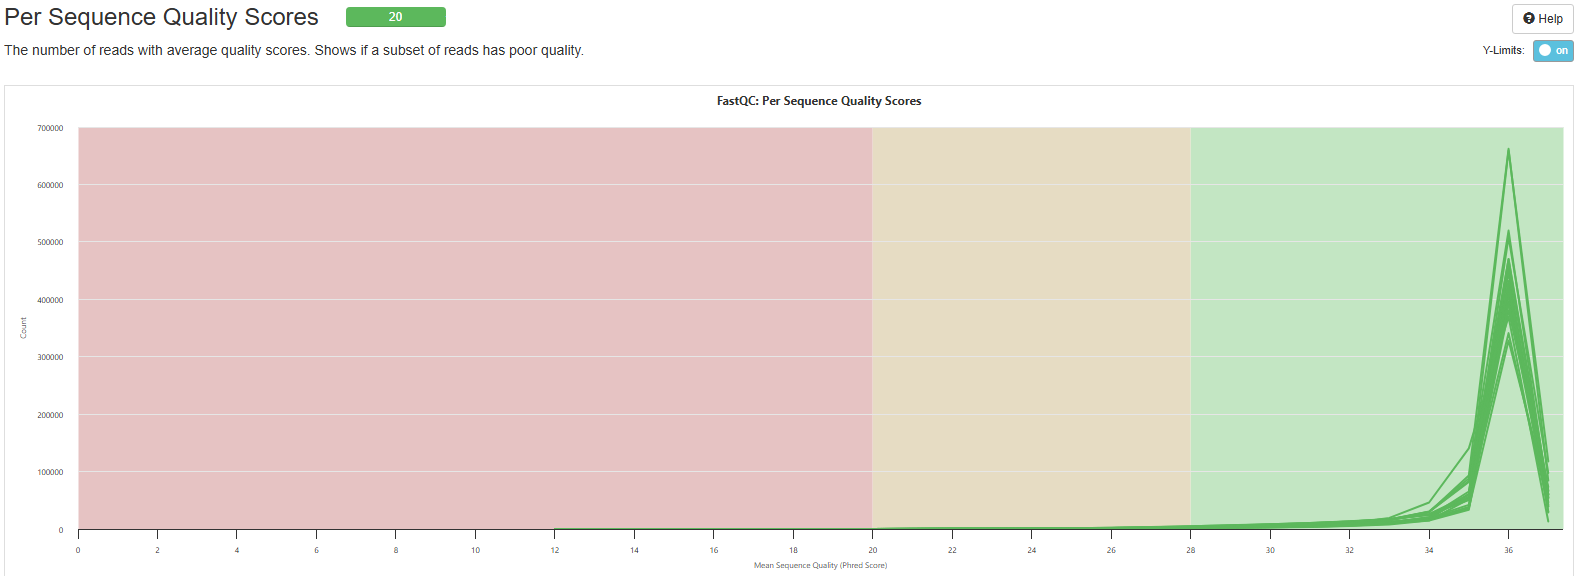

- Average Phred score is around 36. 
- The average Phred score for most samples remains above 30, indicating high-quality reads.

#### 2. Per Base GC Content

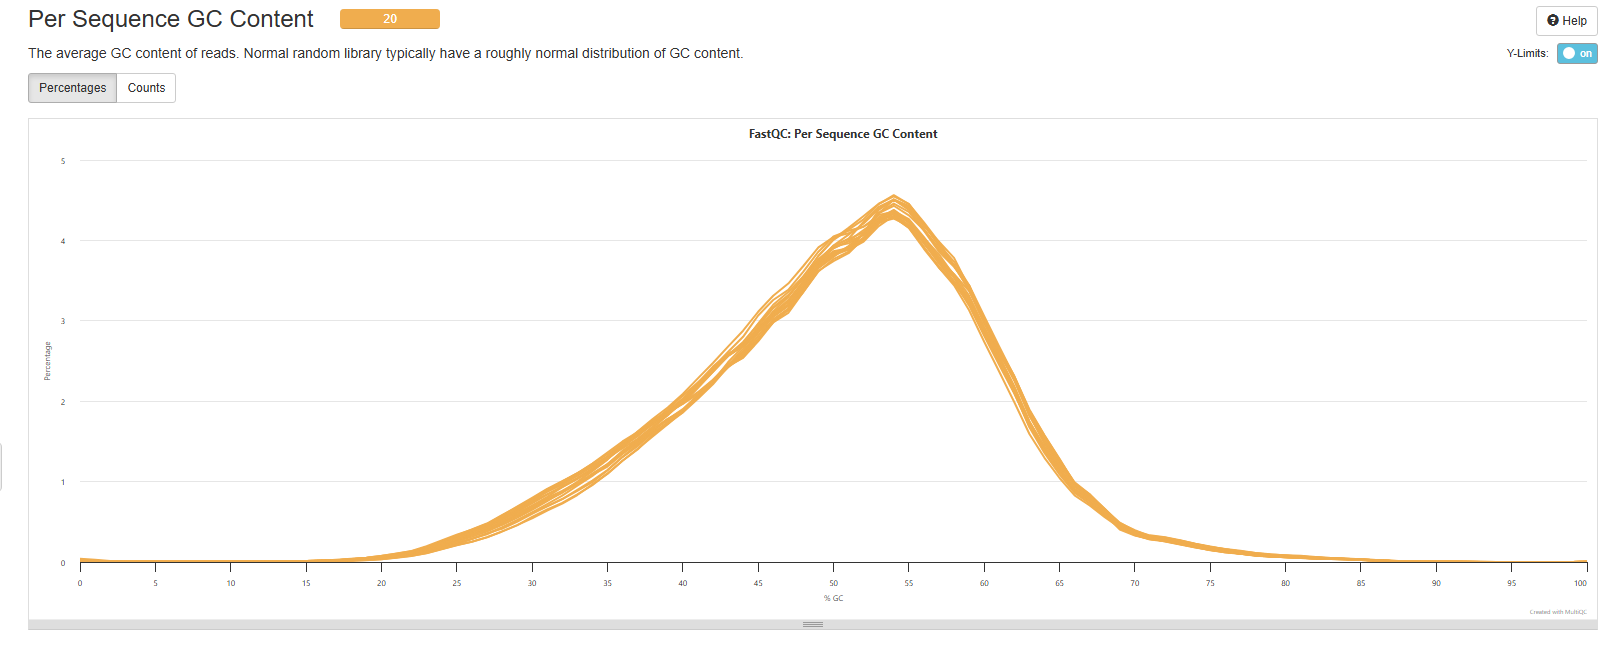

- No unexpected peaks that would indicate contamination.
- Average is around 50-55% which is expected

#### 3. Adapter Content

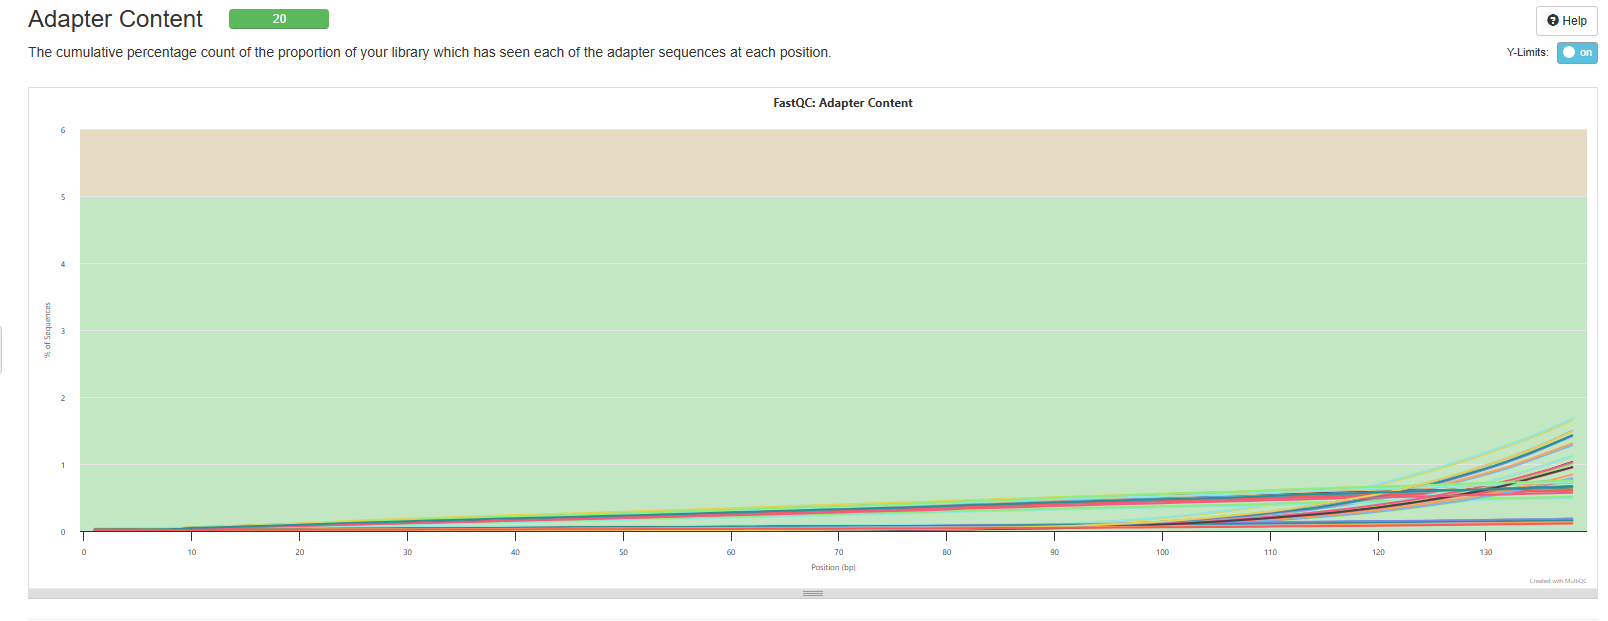

- All samples show minimal adapter contamination, staying below warning thresholds.

#### 4. Sequence Duplication Levels

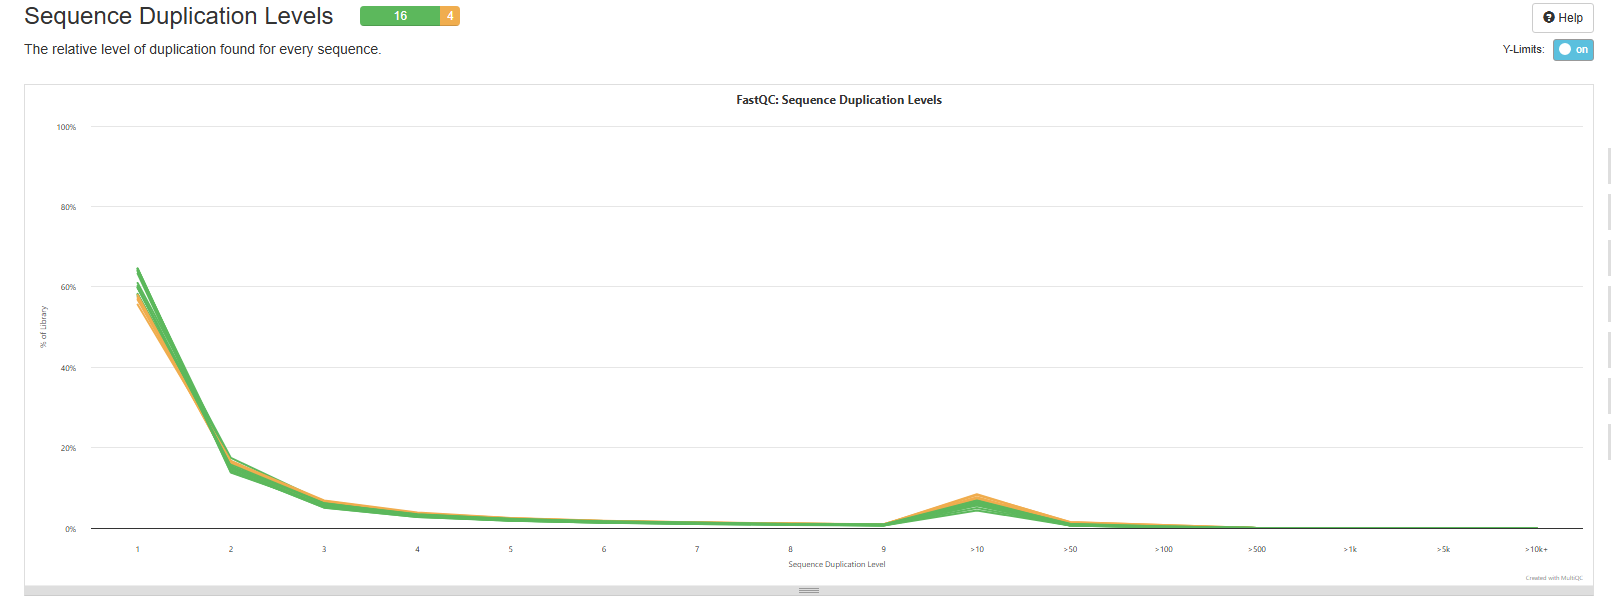

- It can be seen that the duplication levels are low, adding to the quality of the data.

##### Conclusion: - MultiQC confirms that most samples pass quality checks, with only minor warnings.

- gather all files ending in _1.fastq.gz from current directory (we only need one representative from each sample)


In [71]:
files = os.listdir()
mate1 = list()
for file in sorted(files) :
    if file.find('_1.fastq.gz') > -1 :
        mate1.append(file)
        
mate1

['PBS_1_1.fastq.gz',
 'PBS_2_1.fastq.gz',
 'PBS_3_1.fastq.gz',
 'PBS_4_1.fastq.gz',
 'PBS_5_1.fastq.gz',
 'VWF_1_1.fastq.gz',
 'VWF_2_1.fastq.gz',
 'VWF_3_1.fastq.gz',
 'VWF_4_1.fastq.gz',
 'VWF_5_1.fastq.gz']

- check if we can correctly generate second mate file and output prefix:


In [72]:
for file1 in sorted(mate1) :
    file2 = re.sub(r'_1.fastq', '_2.fastq', file1);
    ann = re.sub(r'_1.fastq.+', '_', file1)    
    print(file1, file2, ann)

PBS_1_1.fastq.gz PBS_1_2.fastq.gz PBS_1_
PBS_2_1.fastq.gz PBS_2_2.fastq.gz PBS_2_
PBS_3_1.fastq.gz PBS_3_2.fastq.gz PBS_3_
PBS_4_1.fastq.gz PBS_4_2.fastq.gz PBS_4_
PBS_5_1.fastq.gz PBS_5_2.fastq.gz PBS_5_
VWF_1_1.fastq.gz VWF_1_2.fastq.gz VWF_1_
VWF_2_1.fastq.gz VWF_2_2.fastq.gz VWF_2_
VWF_3_1.fastq.gz VWF_3_2.fastq.gz VWF_3_
VWF_4_1.fastq.gz VWF_4_2.fastq.gz VWF_4_
VWF_5_1.fastq.gz VWF_5_2.fastq.gz VWF_5_


- use the above method to compile and run the STAR command (using mm39 reference genome)

In [73]:
for file1 in sorted(mate1) :
    file2 = re.sub(r'_1.fastq', '_2.fastq', file1);
    ann = re.sub(r'_1.fastq.+', '_', file1)

    # compile job - basic options
    job = 'STAR --genomeLoad LoadAndKeep --genomeDir /data/indices/mm39/star/ --runThreadN 10'

    # input options
    job += f' --readFilesIn {file1} {file2} --readFilesCommand zcat '

    # output options (note that the prefix 'star_' is used here, to quickly identify all generated files)
    job += f' --outFileNamePrefix star_{ann} --outSAMtype BAM SortedByCoordinate --limitBAMsortRAM 10000000000'
    
    print(job + '\n')
    proc = subprocess.run(job, shell=True, stderr=subprocess.PIPE, stdout=subprocess.PIPE, encoding='utf8')

STAR --genomeLoad LoadAndKeep --genomeDir /data/indices/mm39/star/ --runThreadN 10 --readFilesIn PBS_1_1.fastq.gz PBS_1_2.fastq.gz --readFilesCommand zcat  --outFileNamePrefix star_PBS_1_ --outSAMtype BAM SortedByCoordinate --limitBAMsortRAM 10000000000

STAR --genomeLoad LoadAndKeep --genomeDir /data/indices/mm39/star/ --runThreadN 10 --readFilesIn PBS_2_1.fastq.gz PBS_2_2.fastq.gz --readFilesCommand zcat  --outFileNamePrefix star_PBS_2_ --outSAMtype BAM SortedByCoordinate --limitBAMsortRAM 10000000000

STAR --genomeLoad LoadAndKeep --genomeDir /data/indices/mm39/star/ --runThreadN 10 --readFilesIn PBS_3_1.fastq.gz PBS_3_2.fastq.gz --readFilesCommand zcat  --outFileNamePrefix star_PBS_3_ --outSAMtype BAM SortedByCoordinate --limitBAMsortRAM 10000000000

STAR --genomeLoad LoadAndKeep --genomeDir /data/indices/mm39/star/ --runThreadN 10 --readFilesIn PBS_4_1.fastq.gz PBS_4_2.fastq.gz --readFilesCommand zcat  --outFileNamePrefix star_PBS_4_ --outSAMtype BAM SortedByCoordinate --limitBAMs

In [79]:
# rename BAM files
files = os.listdir()
for file in sorted(files) :
    if file.endswith('.bam') :
        new_name = file.replace('_Aligned.sortedByCoord.out', '').replace('star_', '')
        job = f'mv "{file}" "{new_name}"'
        print(job)
        !{job}

mv "star_PBS_1_Aligned.sortedByCoord.out.bam" "PBS_1.bam"
mv "star_PBS_2_Aligned.sortedByCoord.out.bam" "PBS_2.bam"
mv "star_PBS_3_Aligned.sortedByCoord.out.bam" "PBS_3.bam"
mv "star_PBS_4_Aligned.sortedByCoord.out.bam" "PBS_4.bam"
mv "star_PBS_5_Aligned.sortedByCoord.out.bam" "PBS_5.bam"
mv "star_VWF_1_Aligned.sortedByCoord.out.bam" "VWF_1.bam"
mv "star_VWF_2_Aligned.sortedByCoord.out.bam" "VWF_2.bam"
mv "star_VWF_3_Aligned.sortedByCoord.out.bam" "VWF_3.bam"
mv "star_VWF_4_Aligned.sortedByCoord.out.bam" "VWF_4.bam"
mv "star_VWF_5_Aligned.sortedByCoord.out.bam" "VWF_5.bam"


- to see if the mapping worked out, first list all of the BAM files and then extract the percentage of uniquely mapped genes from the STAR log files:

In [96]:
# generate a listing of all the BAM files:
!ls -lrth *.bam

-rw-r--r-- 1 nandakup genomicmed24  83M Mar 28 11:17 PBS_3.bam
-rw-r--r-- 1 nandakup genomicmed24  92M Mar 28 11:17 PBS_4.bam
-rw-r--r-- 1 nandakup genomicmed24  61M Mar 28 11:17 PBS_5.bam
-rw-r--r-- 1 nandakup genomicmed24  76M Mar 28 11:18 VWF_3.bam
-rw-r--r-- 1 nandakup genomicmed24  65M Mar 28 11:18 VWF_4.bam
-rw-r--r-- 1 nandakup genomicmed24 106M Mar 28 11:18 VWF_5.bam


In [99]:
# extract main mapping metric from STAR log files
!grep -i 'Uniquely mapped reads %' *final.out

star_PBS_3_Log.final.out:                        Uniquely mapped reads % |	90.96%
star_PBS_4_Log.final.out:                        Uniquely mapped reads % |	92.57%
star_PBS_5_Log.final.out:                        Uniquely mapped reads % |	91.53%
star_VWF_3_Log.final.out:                        Uniquely mapped reads % |	91.16%
star_VWF_4_Log.final.out:                        Uniquely mapped reads % |	91.56%
star_VWF_5_Log.final.out:                        Uniquely mapped reads % |	92.43%


- since _1 and_2 bam files have low percentage of uniquely mapped reads the files are deleted. Grabbing bam files _3, _4 and _5 for furthur analysis

- The files have > 90% uniquely mapped rates, hence the mapping is excellent

In [100]:
# extract multi mapping metric from STAR log files
!grep -i '% of reads mapped to multiple loci' *final.out

star_PBS_3_Log.final.out:             % of reads mapped to multiple loci |	6.76%
star_PBS_4_Log.final.out:             % of reads mapped to multiple loci |	5.32%
star_PBS_5_Log.final.out:             % of reads mapped to multiple loci |	5.95%
star_VWF_3_Log.final.out:             % of reads mapped to multiple loci |	6.42%
star_VWF_4_Log.final.out:             % of reads mapped to multiple loci |	6.43%
star_VWF_5_Log.final.out:             % of reads mapped to multiple loci |	5.34%


- Multi-mapping percentages are low (below 10%) for all files. Therefor, no parameters have to be adjusted.

In [101]:
# extract unmapped reads metrics from STAR log files
!grep -i '% of reads unmapped: too many mismatches' *final.out
!grep -i '% of reads unmapped: too short' *final.out
!grep -i '% of reads unmapped: other' *final.out

star_PBS_3_Log.final.out:       % of reads unmapped: too many mismatches |	0.00%
star_PBS_4_Log.final.out:       % of reads unmapped: too many mismatches |	0.00%
star_PBS_5_Log.final.out:       % of reads unmapped: too many mismatches |	0.00%
star_VWF_3_Log.final.out:       % of reads unmapped: too many mismatches |	0.00%
star_VWF_4_Log.final.out:       % of reads unmapped: too many mismatches |	0.00%
star_VWF_5_Log.final.out:       % of reads unmapped: too many mismatches |	0.00%
star_PBS_3_Log.final.out:                 % of reads unmapped: too short |	2.13%
star_PBS_4_Log.final.out:                 % of reads unmapped: too short |	1.92%
star_PBS_5_Log.final.out:                 % of reads unmapped: too short |	2.34%
star_VWF_3_Log.final.out:                 % of reads unmapped: too short |	2.32%
star_VWF_4_Log.final.out:                 % of reads unmapped: too short |	1.88%
star_VWF_5_Log.final.out:                 % of reads unmapped: too short |	2.07%
star_PBS_3_Log.final.out:   

- Since all of the percentages are below 3%, they can be ignored

- Therefore, the mapping quality is really good

In [75]:
# move all STAR files into a sub-directory to keep the main content tidy
!mkdir STAR
!mv star_* STAR

- for the next step we need an annotation file - link or download it into this directory

In [83]:
annotation_file = 'Mus_musculus.GRCm39.113.chr.gtf.gz'
if os.path.exists('/data/genomes/mouse/mm39/' + annotation_file) :
    print('linking annotationfile from shared directory')
    !ln -s /data/genomes/mouse/mm39/{annotation_file} .
else :
    print('downloading annotation file from Ensembl')
    !curl -LO https://ftp.ensembl.org/pub/current_gtf/mus_musculus/Mus_musculus.GRCm39.113.chr.gtf.gz

linking annotationfile from shared directory


- to see proper gene names in the results, use the 'gene_name' field, but for this to work we can only use entries that have this kind of information:

In [84]:
!zgrep gene_name {annotation_file} > mm39_annotation.gtf

- now create a read count matrix using featureCounts:

- Check with forward, reverse and unstranded options to see which gives best percentage of alignemnts

##### unstranded alignemnt

In [111]:
!featureCounts -a mm39_annotation.gtf -g gene_name -o gene_counts_s0 -T 10 -s 0 -p *.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.6

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 6 BAM files                                      ||
||                                                                            ||
||                           PBS_3.bam                                        ||
||                           PBS_4.bam                                        ||
||                           PBS_5.bam                           

##### forward stranded alignment

In [112]:
!featureCounts -a mm39_annotation.gtf -g gene_name -o gene_counts_s1 -T 10 -s 1 -p *.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.6

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 6 BAM files                                      ||
||                                                                            ||
||                           PBS_3.bam                                        ||
||                           PBS_4.bam                                        ||
||                           PBS_5.bam                           

##### reverse stranded alignment

In [113]:
!featureCounts -a mm39_annotation.gtf -g gene_name -o gene_counts_s2 -T 10 -s 2 -p *.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.0.6

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 6 BAM files                                      ||
||                                                                            ||
||                           PBS_3.bam                                        ||
||                           PBS_4.bam                                        ||
||                           PBS_5.bam                           

- Check assigned number of reads for all three strandedness

In [114]:
# Check total assigned reads
!grep "Assigned" gene_counts_s0.summary
!grep "Assigned" gene_counts_s1.summary
!grep "Assigned" gene_counts_s2.summary

Assigned	1106219	1224216	794119	1030932	888246	1510421
Assigned	624740	684116	445624	579579	497769	816406
Assigned	620301	682502	443871	578151	499233	858433


- Since both forward and reverse stranded are showing < 50% , the mapping is not strand specific
- Unstrandedness gives better alignment rate (> 75% for all files) and so proceeding with the genecounts matrix of the same

In [115]:
# copy unstranded genecounts matrix
cp gene_counts_s0 gene_counts

- clean up the read matrix by extracting the first column (ID) and the last ones (read counts), excluding gene annotation:

In [116]:
!cut -f 1,7-99 gene_counts > gene_counts2

- then exclude the comment line (take everything from second line onwards) and take a look:

In [117]:
!tail -n +2 gene_counts2 > count_matrix.tsv
!head count_matrix.tsv

Geneid	PBS_3.bam	PBS_4.bam	PBS_5.bam	VWF_3.bam	VWF_4.bam	VWF_5.bam
Gm38212	0	0	0	0	0	0
Gm7449	0	0	0	0	0	0
Gm28283	0	0	0	0	0	0
Gm37108	0	2	0	0	2	0
Gm37275	0	0	0	0	0	0
Gm6679	0	0	0	0	0	0
Gm29155	0	0	0	0	0	0
Gm37225	0	0	0	0	0	0
Gm17847	0	0	0	0	0	0


- sort file to see which gene has the highest expression, say, in the PBS_3 sample:

In [118]:
!sort -k2nr count_matrix.tsv | head

Apoe	17285	16206	9665	13900	12785	13625
Lyz2	16918	16318	11059	11459	9609	15512
Fth1	16394	12648	9048	18695	15977	17846
Ctsb	15001	18877	12109	10697	8895	18397
Psap	12389	15397	9554	8476	7614	13121
Ctsd	12285	8392	6547	8279	6350	7297
Actb	9988	9488	6766	11142	10596	13870
Tmsb4x	8537	5448	4476	7369	6175	6948
Lgals3	8264	6456	5418	5128	4137	6500
Eef1a1	7826	8764	5656	6636	5657	10321
sort: write failed: 'standard output': Broken pipe
sort: write error


- It can be seen that Apoe, Lyz2, Fth1, Ctsb, Psap, Ctsd, Actb genes have highest expression

# DESeq2 analysis

- clean up the headers of the read count matrix and remove genes that are lowly expressed across all samples

In [126]:
# Open file-handle to matrix file for reading
f = open('count_matrix.tsv')
header = f.readline()

# Open file-handle for writing
# To keep it consistent, use 'tsv' ending again
outfile = 'clean_matrix.tsv'
fout = open(outfile, 'w')

# clean header and write to file
header = header.replace('.bam', '')

# header line has not been stripped off white space so no need to add a newline here
fout.write(header)

#Cycle through each line
for line in f :
    
    # split at tab (into GeneID and values)
    parts = line.strip().split('\t')

    # sum up expression values
    expression = 0
    for pos in range(1, len(parts)) :
        expression += int(parts[pos])
        
    # alternatively, this can be achieved in one line using the 'map' function
    # to convert the elements with digits in our list into integers
    # and the function 'sum' to add them up:
    expression = sum(map(int, parts[1:len(parts)]))
    
    # There is no correct level for setting a filter cut-off
    # Permitting genes to get through where one set of replicates has zero expression 
    # and the other set has 5 reads on average sounds reasonable
    # so 3 * 5 rounded up to 20 should get rid of most lowly expressed genes without 
    # catching too many higher expressed genes
    # The best would be to run the DEG analysis with different cut-offs and compare the results
    # then decide on a value based on what makes most sense biologically
    # Even better would be to take the length of a gene into account but that would go beyond the scope of this module
    if expression >= 20 :
        # write line to file if expression high enough
        fout.write(line)
    
# Close file-handles
f.close()
fout.close()

In [127]:
# count the number of lines within the two matrix files
!wc -l *matrix*

  10759 clean_matrix.tsv
  56096 count_matrix.tsv
  66855 total


- When expression threshold is kept as 20, 10759 reads were assigned into clean_matrix from 56096 reads of count_matrix

In [128]:
# define input and output files in variables
# so they can be easily changed in one place if necessary:
matrix_file = 'clean_matrix.tsv'
meta_file = 'sample_description.txt'

- from the read count matrix we can generate a sample information file that correlates column headers with experimental conditions

In [129]:
# generate a sample meta file by using the header line from the count matrix
# to make sure the correct sample names and sample order is preserved

# regular expressions will be used in the process
import re

# get the first line from the count matrix
# which contains the column name for the Gene IDs followed
# by column names for the samples; split them into a list
fin = open(matrix_file)
sample_order = fin.readline().strip().split('\t')

# write the header line to the output file:
fout = open(meta_file, 'w')
fout.write('name\tcondition\n')

# process each sample name in order
for pos in range(1, len(sample_order)) :
    sample = sample_order[pos]
    
    # the first regular expression matches the condition and the biological replicate number individually
    # the second uses back references to print the sample name followed by a tab and the condition
    sample = re.sub(r'(.+)(_\d)', r'\1\2\t\1', sample)
    fout.write(sample + '\n')
               
fout.close()
fin.close()   

!cat {meta_file}

name	condition
PBS_3	PBS
PBS_4	PBS
PBS_5	PBS
VWF_3	VWF
VWF_4	VWF
VWF_5	VWF


- we now have the necessary files in place to run DESeq2 wrapper

In [130]:
!DESeq2_wrapper {matrix_file} {meta_file}


DESeq2 analysis started on Fri Mar 28 12:00:29 2025...
DESeq2 analysis finished successfully.
Log messages have been printed to DESeq2_wrapper.log


- check which contrast was carried out in the statistical test:

In [136]:
!grep 'Wald test' DESeq2_wrapper.log

Wald test p-value: condition VWF vs PBS 


- take a look at the main results, which contains genes sorted by adjusted p-value:

In [137]:
!head DESeq2.de_all.tsv | cut -f 1,2,3,7 > deseq2_reduced.tsv

In [138]:
!head deseq2_reduced.tsv

	baseMean	log2FoldChange	padj
Rsad2	1435.67133802273	7.14591621337977	4.77462573259794e-124
Tnf	1591.88892644472	4.40881988409014	1.58428376398259e-104
Tnfaip2	2606.87271999049	4.19688208540233	3.39387513019898e-98
Ccl4	2165.45209648914	4.81485781699151	7.4372947761018e-91
Ifit1	1317.35763306366	9.25896349434513	1.09228404127609e-89
Cd40	484.75350845102	6.2898080354535	2.8570428511321e-85
Socs3	668.714897491024	7.92010446412476	2.8570428511321e-85
Ifit3	440.007672255485	5.93929213028651	3.50286570602283e-78
Cdkn1a	1019.8147183718	3.41694024459229	7.21206960320706e-68


- convert BAM files into BigWigs to view coverage information in IGV

In [144]:
files = os.listdir()
for file in sorted(files) :
    if file.endswith('.bam') :
        print(file)

PBS_3.bam
PBS_4.bam
PBS_5.bam
VWF_3.bam
VWF_4.bam
VWF_5.bam


In [142]:
files = os.listdir()
for file in sorted(files) :
    if file.endswith('.bam') :
        bigwig = file.replace('.bam', '.bw')
        job = f'samtools index {file}; time bamCoverage -b {file} -o {bigwig} -p 10 --minMappingQuality 225 --normalizeUsing CMP > bamcoverage.log 2> bamcoverage.err'
        print(job)
        !{job}

samtools index PBS_3.bam; time bamCoverage -b PBS_3.bam -o PBS_3.bw -p 10 --minMappingQuality 225 --normalizeUsing CMP > bamcoverage.log 2> bamcoverage.err

real	0m0.225s
user	0m0.193s
sys	0m0.032s
samtools index PBS_4.bam; time bamCoverage -b PBS_4.bam -o PBS_4.bw -p 10 --minMappingQuality 225 --normalizeUsing CMP > bamcoverage.log 2> bamcoverage.err

real	0m0.332s
user	0m0.281s
sys	0m0.051s
samtools index PBS_5.bam; time bamCoverage -b PBS_5.bam -o PBS_5.bw -p 10 --minMappingQuality 225 --normalizeUsing CMP > bamcoverage.log 2> bamcoverage.err

real	0m0.379s
user	0m0.322s
sys	0m0.057s
samtools index VWF_3.bam; time bamCoverage -b VWF_3.bam -o VWF_3.bw -p 10 --minMappingQuality 225 --normalizeUsing CMP > bamcoverage.log 2> bamcoverage.err

real	0m0.344s
user	0m0.297s
sys	0m0.046s
samtools index VWF_4.bam; time bamCoverage -b VWF_4.bam -o VWF_4.bw -p 10 --minMappingQuality 225 --normalizeUsing CMP > bamcoverage.log 2> bamcoverage.err

real	0m0.334s
user	0m0.281s
sys	0m0.053s
samtools i

In [146]:
!ls *bw

ls: cannot access '*bw': No such file or directory


In [147]:
files = os.listdir()

bamfiles = list()
for file in files :
    if file.endswith('.bam') :
        bamfiles.append(file)
        
bamfiles

['PBS_3.bam', 'VWF_3.bam', 'VWF_4.bam', 'PBS_4.bam', 'PBS_5.bam', 'VWF_5.bam']

In [148]:
# cycle through each bam file and process it
for bam in bamfiles :
    
    infile = bam
    outfile = bam.replace('.bam', '.bw')
    
    job = f'samtools index {infile}; bamCoverage -b {infile} -o {outfile} --normalizeUsing CPM -p 4'
    print(job)

    # comment out next line to run full process
    # continue
    
    # run job and capture both STDOUT and STDERR
    proc = subprocess.run(job, shell=True, stderr=subprocess.PIPE, stdout=subprocess.PIPE, encoding='utf8')

    # stop script if an error occurred:
    #if proc.stderr :
     #   raise Exception(proc.stderr)
    # print normal output
    print(proc.stdout)
    print(proc.stderr)

samtools index PBS_3.bam; bamCoverage -b PBS_3.bam -o PBS_3.bw --normalizeUsing CPM -p 4

normalization: CPM
bamFilesList: ['PBS_3.bam']
binLength: 50
numberOfSamples: None
blackListFileName: None
skipZeroOverZero: False
bed_and_bin: False
genomeChunkSize: None
defaultFragmentLength: read length
numberOfProcessors: 4
verbose: False
region: None
bedFile: None
minMappingQuality: None
ignoreDuplicates: False
chrsToSkip: []
stepSize: 50
center_read: False
samFlag_include: None
samFlag_exclude: None
minFragmentLength: 0
maxFragmentLength: 0
zerosToNans: False
smoothLength: None
save_data: False
out_file_for_raw_data: None
maxPairedFragmentLength: 1000

samtools index VWF_3.bam; bamCoverage -b VWF_3.bam -o VWF_3.bw --normalizeUsing CPM -p 4

normalization: CPM
bamFilesList: ['VWF_3.bam']
binLength: 50
numberOfSamples: None
blackListFileName: None
skipZeroOverZero: False
bed_and_bin: False
genomeChunkSize: None
defaultFragmentLength: read length
numberOfProcessors: 4
verbose: False
region: No

## Results
### 1. PCA plot

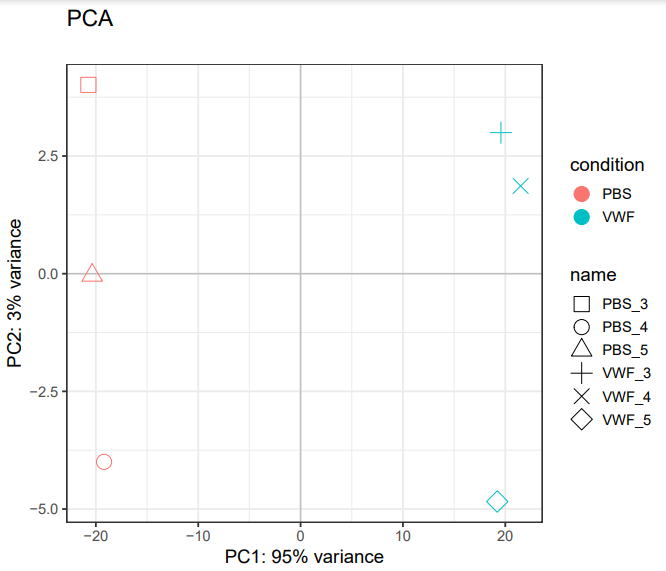

- PBS vs VWF treatment shows clustering within and captures 95% variance among the groups.
- This shows good amount of differential gene expression between them

### 2. table of top differentially expressed genes (from deseq2_reduced.tsv, top 9 according to p-value)

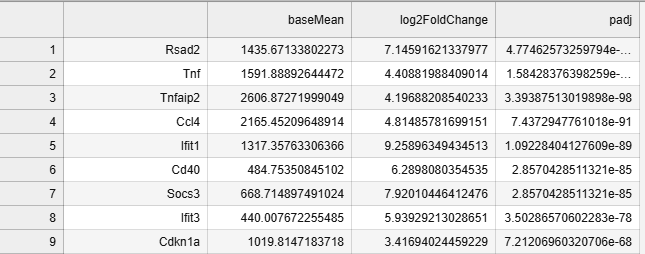

### 3. Visualization in IGV

#### CCL4

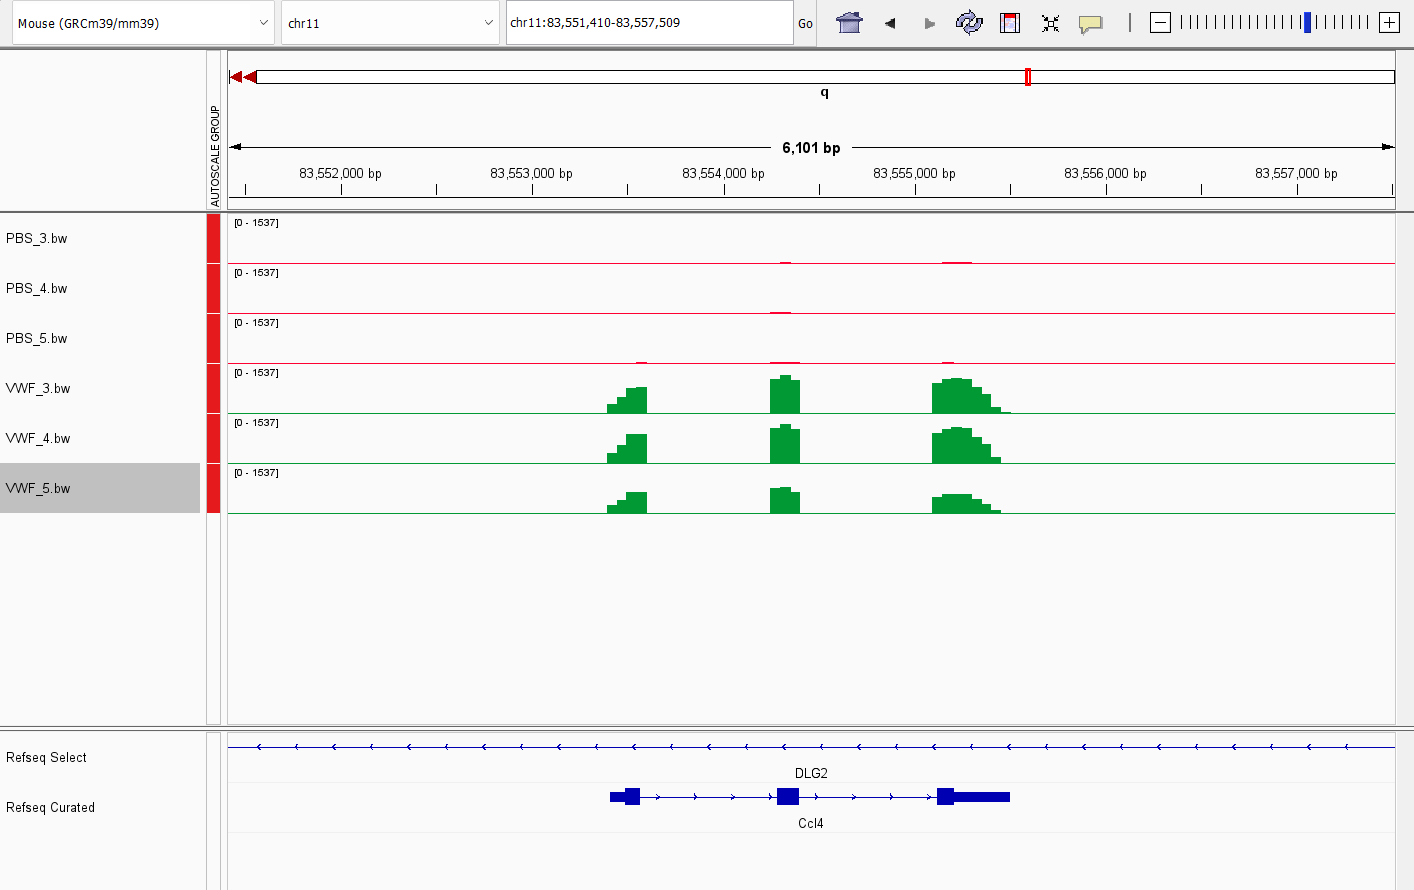

- CCL4 is a pro-inflammatory chemokine which is shown to be one of the highest differentially expressed. 
- From IGV, it can be seen that CCL4 is highly expressed in VBF treated samples.
- This gives evidence for the study saying VBF drives inflammatory response.

#### CD40

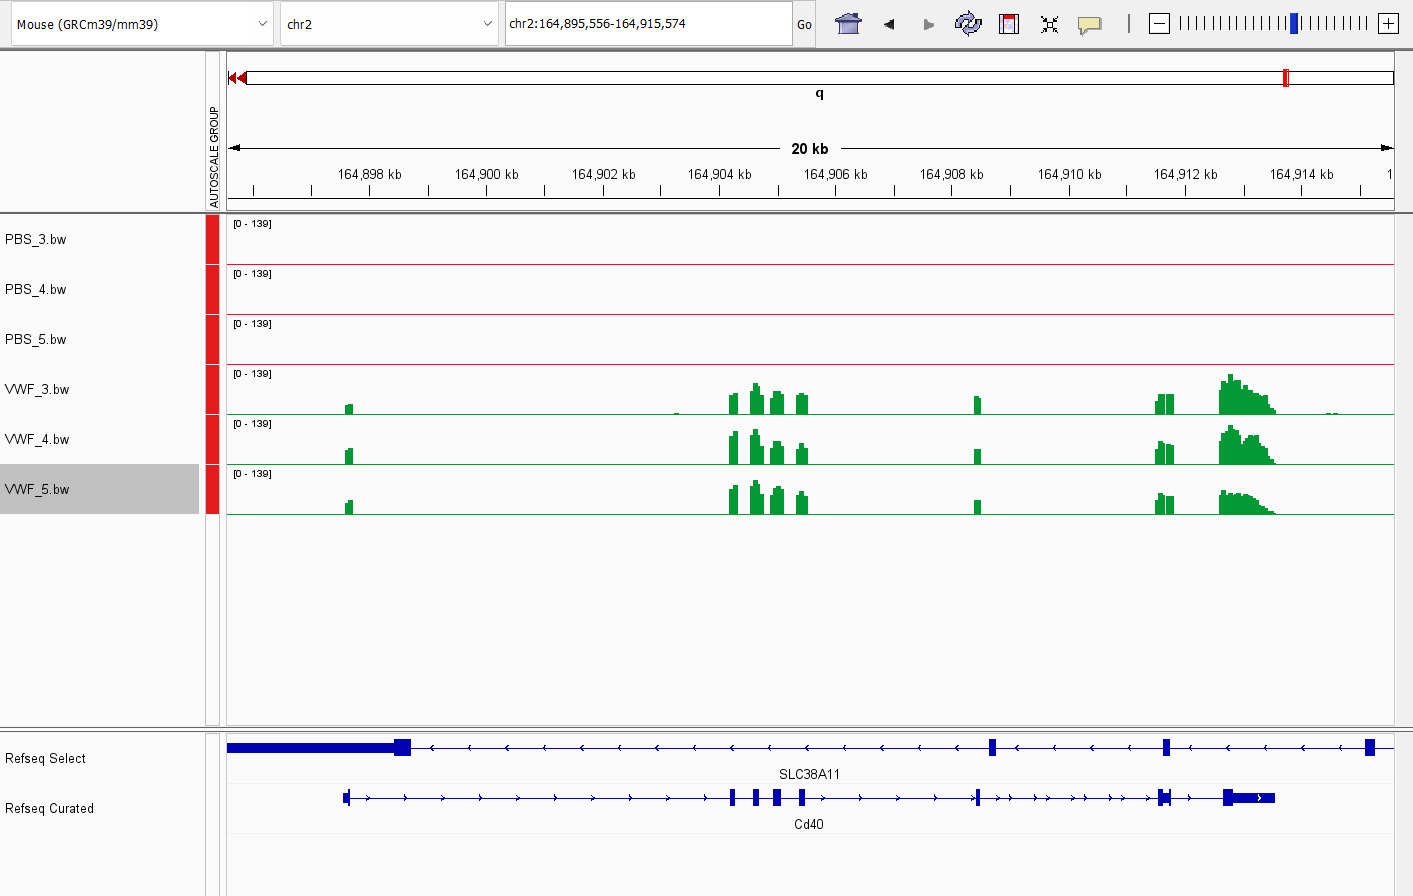

- CD40 is a pro-inflammatory cytokine which is shown to be one of the highest differentially expressed. 
- From IGV, it can be seen that CCL4 is highly expressed in VBF treated samples.
- The presence of the surface CD40 receptor augments the immune-inflammatory process.


#### iDEP analysis

In [149]:
matrix = 'clean_matrix.tsv'

# name of output file
design_file = 'idep_design_file.tsv'

# open filehandles
fh_in = open(matrix)
fh_out = open(design_file, 'w')

# read in header line from matrix to get order and names of samples
header = fh_in.readline()

# write to design file
fh_out.write(header)

# split header into list (separated by tab):
parts = header.strip().split('\t')

# define a string that will contain design info:
design = 'Gene'

# go through samples, remove biological replicate to derive condition
# and add to output string:
for pos in range(1, len(parts)) :
    sample = parts[pos]
    condition = re.sub(r'_\d$', '', sample)    
    design += '\t' + condition
    
# write design to output file
fh_out.write(design + '\n')

# close filehandles
fh_out.close()
fh_in.close()

### Evaluation of results

#### 1. Volcano plot

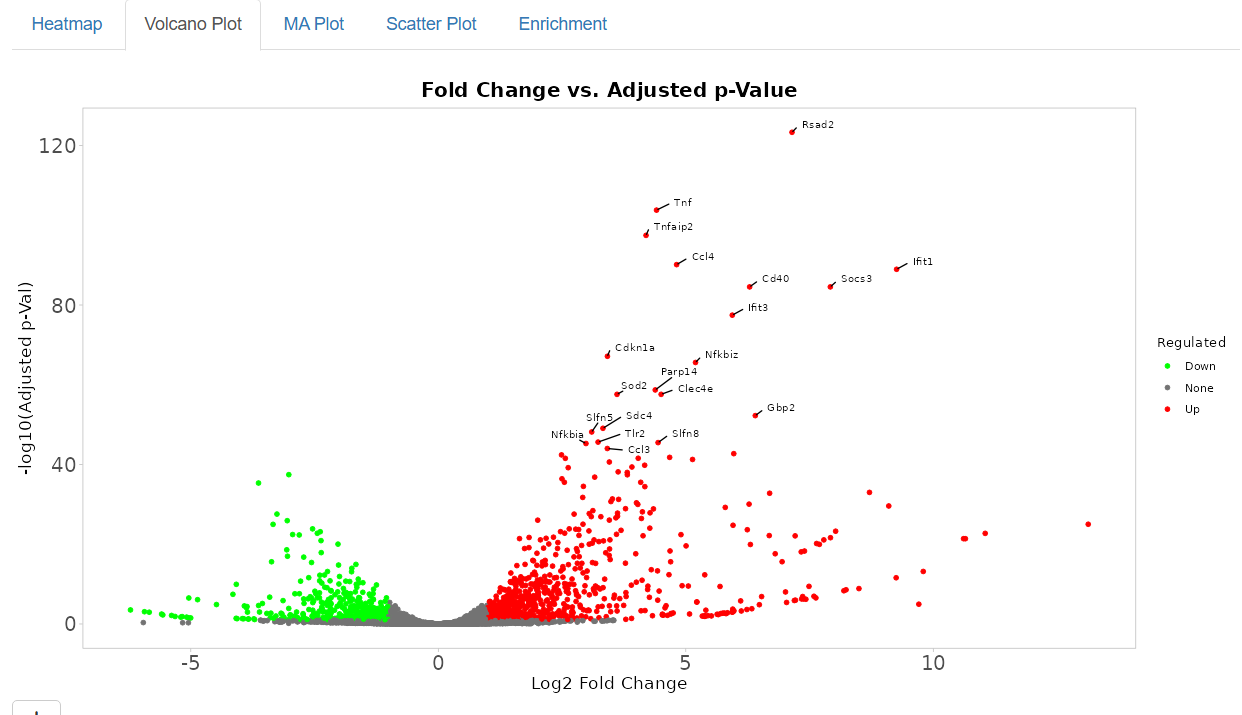

- Quite follows the same design as the study where highly expressed genes are more than lowly expressed.
- TNF, CCL4 etc from the study can be seen in the plot too.

#### 2. Heatmap

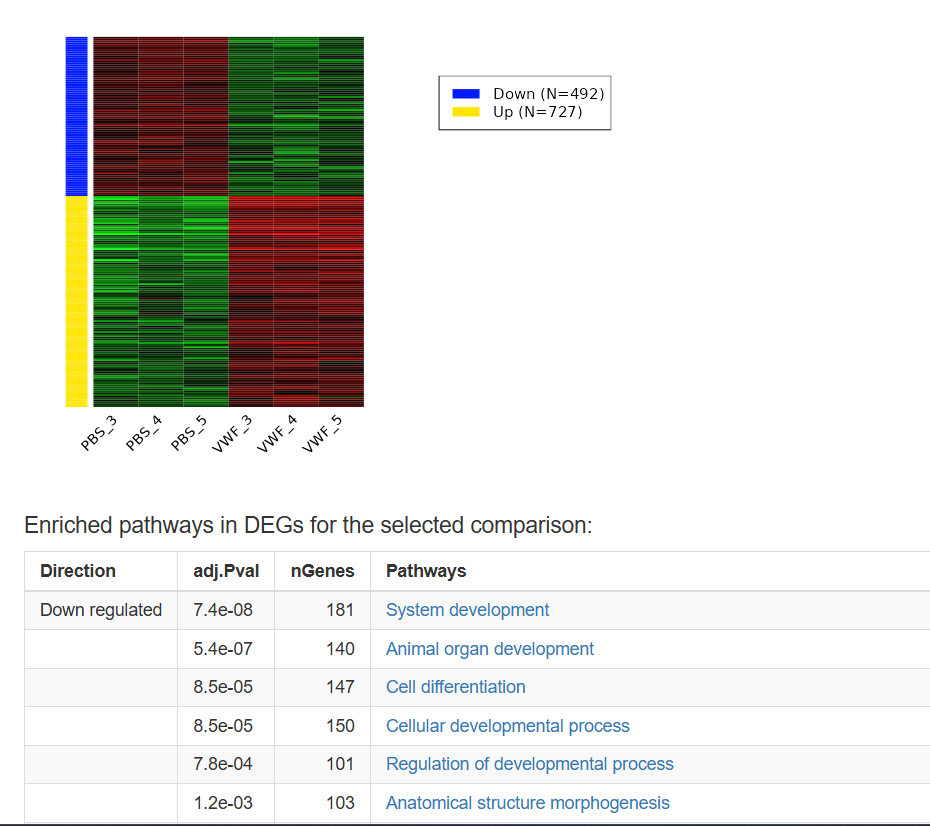

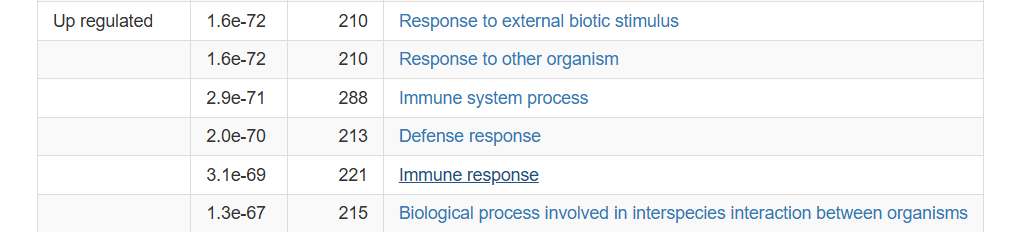

- From heatmap analysis in iDEP, it can be seen the immune responses are upregulated, which is connected to pro-inflammatory signals as the studies says.

### Comparison of results with published study:


- Did these genes show up in your analysis (with similar fold-changes / p-values)? If not, can you think of reasons? Did you get any additional genes? If so, could they be important?

### Kallisto mapping

In [157]:
# start from current directory
os.chdir(os.path.expanduser("/home/nandakup/ICGDH-II_assessment/24336825_new"))

# create a new directory for this analysis step and change into it
directory = 'kallisto'
if not os.path.exists(directory):
    os.makedirs(directory)
os.chdir(directory)

# link small data files into working directory
!ln -s /home/nandakup/ICGDH-II_assessment/24336825_new/*fastq.gz .

# list linked files:
!ls -lLh *fastq.gz

ln: failed to create symbolic link './PBS_3_1.fastq.gz': File exists
ln: failed to create symbolic link './PBS_3_2.fastq.gz': File exists
ln: failed to create symbolic link './PBS_4_1.fastq.gz': File exists
ln: failed to create symbolic link './PBS_4_2.fastq.gz': File exists
ln: failed to create symbolic link './PBS_5_1.fastq.gz': File exists
ln: failed to create symbolic link './PBS_5_2.fastq.gz': File exists
ln: failed to create symbolic link './VWF_3_1.fastq.gz': File exists
ln: failed to create symbolic link './VWF_3_2.fastq.gz': File exists
ln: failed to create symbolic link './VWF_4_1.fastq.gz': File exists
ln: failed to create symbolic link './VWF_4_2.fastq.gz': File exists
ln: failed to create symbolic link './VWF_5_1.fastq.gz': File exists
ln: failed to create symbolic link './VWF_5_2.fastq.gz': File exists
-rw-r--r-- 1 root bioinf 38M Mar 27 21:21 PBS_1_1.fastq.gz
-rw-r--r-- 1 root bioinf 39M Mar 27 21:21 PBS_1_2.fastq.gz
-rw-r--r-- 1 root bioinf 35M Mar 27 21:21 PBS_2_1.fast

In [158]:
# get all files ending in _1.fastq.gz from current directory
files = os.listdir()
mate1 = list()
for file in files :
    if file.endswith('_1.fastq.gz') :
        mate1.append(file)
        
mate1

['PBS_5_1.fastq.gz',
 'VWF_3_1.fastq.gz',
 'PBS_3_1.fastq.gz',
 'PBS_4_1.fastq.gz',
 'VWF_5_1.fastq.gz',
 'VWF_4_1.fastq.gz']

In [159]:
# generate second mate file and output prefix:
for file1 in sorted(mate1) :
    file2 = re.sub(r'_1.fastq', '_2.fastq', file1);
    ann = re.sub(r'_1.fastq.+', '', file1)    
    print(file1, file2, ann)

PBS_3_1.fastq.gz PBS_3_2.fastq.gz PBS_3
PBS_4_1.fastq.gz PBS_4_2.fastq.gz PBS_4
PBS_5_1.fastq.gz PBS_5_2.fastq.gz PBS_5
VWF_3_1.fastq.gz VWF_3_2.fastq.gz VWF_3
VWF_4_1.fastq.gz VWF_4_2.fastq.gz VWF_4
VWF_5_1.fastq.gz VWF_5_2.fastq.gz VWF_5


In [160]:
# generate kallisto command
for file1 in sorted(mate1) :
    file2 = re.sub(r'_1.fastq', '_2.fastq', file1);
    ann = re.sub(r'_1.fastq.+', '', file1)

    # compile job - make sure to get the strandedness right!
    job = 'kallisto quant -i /data/indices/mm39/kallisto/mm39.cdna.idx -t 4 --rf-stranded'

    # input options
    job += f' {file1} {file2}'

    # output options
    #job += f' -o kallisto_out_{ann}'
    job += f' -o kallisto_out_{ann} 2> {ann}.log' #log contaning std errors
    
    print(job)
    # NOTE: remove comments from below to run the actual commands:
    proc = subprocess.run(job, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, encoding='utf8')
    print('STDOUT: ', proc.stdout)
    print('STDERR: ', proc.stderr)

kallisto quant -i /data/indices/mm39/kallisto/mm39.cdna.idx -t 4 --rf-stranded PBS_3_1.fastq.gz PBS_3_2.fastq.gz -o kallisto_out_PBS_3 2> PBS_3.log
STDOUT:  
STDERR:  
kallisto quant -i /data/indices/mm39/kallisto/mm39.cdna.idx -t 4 --rf-stranded PBS_4_1.fastq.gz PBS_4_2.fastq.gz -o kallisto_out_PBS_4 2> PBS_4.log
STDOUT:  
STDERR:  
kallisto quant -i /data/indices/mm39/kallisto/mm39.cdna.idx -t 4 --rf-stranded PBS_5_1.fastq.gz PBS_5_2.fastq.gz -o kallisto_out_PBS_5 2> PBS_5.log
STDOUT:  
STDERR:  
kallisto quant -i /data/indices/mm39/kallisto/mm39.cdna.idx -t 4 --rf-stranded VWF_3_1.fastq.gz VWF_3_2.fastq.gz -o kallisto_out_VWF_3 2> VWF_3.log
STDOUT:  
STDERR:  
kallisto quant -i /data/indices/mm39/kallisto/mm39.cdna.idx -t 4 --rf-stranded VWF_4_1.fastq.gz VWF_4_2.fastq.gz -o kallisto_out_VWF_4 2> VWF_4.log
STDOUT:  
STDERR:  
kallisto quant -i /data/indices/mm39/kallisto/mm39.cdna.idx -t 4 --rf-stranded VWF_5_1.fastq.gz VWF_5_2.fastq.gz -o kallisto_out_VWF_5 2> VWF_5.log
STDOUT:  
ST

In [181]:
# get all files starting with 'kallisto_out_'
files = os.listdir()
kallisto_dirs = list()
for file in sorted(files) :
    if file.startswith('kallisto_out_') :
        kallisto_dirs.append(file)
        
kallisto_dirs

['kallisto_out_PBS_3',
 'kallisto_out_PBS_4',
 'kallisto_out_PBS_5',
 'kallisto_out_VWF_3',
 'kallisto_out_VWF_4',
 'kallisto_out_VWF_5']

In [182]:
# generate kallisto matrix (using dictionary of lists):
matrix = dict()
for kallisto in sorted(kallisto_dirs) :
    count_file = kallisto + '/abundance.tsv'
    fh = open(count_file)
    header = fh.readline()
    for line in fh :
        parts = line.strip().split('\t')
        transcript = parts[0]
        
        if not transcript in matrix :
            matrix[transcript] = list()
            
        counts = parts[3]
        matrix[transcript].append(counts)
        
    fh.close()

In [193]:
out_file = 'kallisto_readcounts.tsv'
fout = open(out_file, 'w')
header_out = 'TranscriptID'
cols = list()
for kallisto in sorted(kallisto_dirs) :
    ann = re.sub(r'kallisto_out_', '', kallisto)
    cols.append(ann)
    header_out += '\t' + ann
fout.write(header_out + '\n')

for transcript in matrix :
#    in case of removal of version number is required:
#    out = re.sub(r'\.\d+', '', transcript)
    out = transcript
    
    if type(matrix[transcript]) is list :
        out += '\t' + "\t".join(matrix[transcript])
    else :
        for ann in cols :
            out += f'\t{int(matrix[transcript][ann])}'
#        in case of rounding to full integers is required:
            #out += f'\t{float(matrix[transcript][ann]):.0f}'
         #   out += '\t' + matrix[transcript][ann]
        
    fout.write(out + '\n')

fout.close()

In [194]:
!sort -k2nr {out_file} | head

ENSMUST00000094434.13	10639.6	7410.28	5680.1	6846.57	6126.57	6181.13
ENSMUST00000025563.8	5772.57	5105.17	3535.52	6732.21	5681.21	7596.92
ENSMUST00000151120.9	5282	4434.87	3265.07	3360.44	2642.22	3999.83
ENSMUST00000092163.9	4550	4508	2935	3011	2673	4321
ENSMUST00000006235.9	3708.66	4320.08	2789.22	2657.87	2239.38	4583.39
ENSMUST00000174355.8	3064.98	2472.86	1593.06	2535.93	2228.04	2368.84
ENSMUST00000042235.15	2613.1	2787.11	1836.35	2295.64	1934.64	3407.22
ENSMUST00000100497.11	2251.92	2190.83	1594.11	2494.93	2426.75	3090.46
ENSMUST00000112172.4	2184.19	1327.97	1089.79	1835.8	1532.86	1805.23
ENSMUST00000031840.10	1744.04	2833.13	1777.4	1096.44	1030.52	2924.98
sort: write failed: 'standard output': Broken pipe
sort: write error


- Kallisto does not seem to give out integer results so not proceeding with it

### Bowtie2 mappaing

In [197]:
# start from current directory
os.chdir(os.path.expanduser("/home/nandakup/ICGDH-II_assessment/24336825_new"))

# create a new directory for this analysis step and change into it
directory = 'Bowtie2'
if not os.path.exists(directory):
    os.makedirs(directory)
os.chdir(directory)

# link chr1 files from shared directory into current working directory
!ln -s /home/nandakup/ICGDH-II_assessment/24336825_new/*.gz .

# list linked files:
!ls -lLh *fastq.gz

-rw-r--r-- 1 root bioinf 38M Mar 27 21:21 PBS_1_1.fastq.gz
-rw-r--r-- 1 root bioinf 39M Mar 27 21:21 PBS_1_2.fastq.gz
-rw-r--r-- 1 root bioinf 35M Mar 27 21:21 PBS_2_1.fastq.gz
-rw-r--r-- 1 root bioinf 36M Mar 27 21:21 PBS_2_2.fastq.gz
-rw-r--r-- 1 root bioinf 45M Mar 27 21:02 PBS_3_1.fastq.gz
-rw-r--r-- 1 root bioinf 46M Mar 27 21:03 PBS_3_2.fastq.gz
-rw-r--r-- 1 root bioinf 49M Mar 27 21:03 PBS_4_1.fastq.gz
-rw-r--r-- 1 root bioinf 50M Mar 27 21:04 PBS_4_2.fastq.gz
-rw-r--r-- 1 root bioinf 32M Mar 27 21:04 PBS_5_1.fastq.gz
-rw-r--r-- 1 root bioinf 33M Mar 27 21:04 PBS_5_2.fastq.gz
-rw-r--r-- 1 root bioinf 40M Mar 27 21:21 VWF_1_1.fastq.gz
-rw-r--r-- 1 root bioinf 43M Mar 28 11:37 VWF_1_2.fastq.gz
-rw-r--r-- 1 root bioinf 38M Mar 27 21:21 VWF_2_1.fastq.gz
-rw-r--r-- 1 root bioinf 38M Mar 27 21:21 VWF_2_2.fastq.gz
-rw-r--r-- 1 root bioinf 42M Mar 27 20:48 VWF_3_1.fastq.gz
-rw-r--r-- 1 root bioinf 43M Mar 28 11:53 VWF_3_2.fastq.gz
-rw-r--r-- 1 root bioinf 35M Mar 27 20:48 VWF_4_1.fastq.

In [198]:
# get all files ending in .fastq.gz from current directory
files = os.listdir()
fastq = list()
for file in files :
    if file.find('.fastq.gz') > -1 :
        fastq.append(file)
        
fastq

['PBS_3_2.fastq.gz',
 'VWF_5_2.fastq.gz',
 'PBS_4_2.fastq.gz',
 'PBS_5_2.fastq.gz',
 'PBS_5_1.fastq.gz',
 'VWF_3_1.fastq.gz',
 'PBS_3_1.fastq.gz',
 'VWF_4_2.fastq.gz',
 'PBS_4_1.fastq.gz',
 'VWF_3_2.fastq.gz',
 'VWF_5_1.fastq.gz',
 'VWF_4_1.fastq.gz']

In [199]:
# generate output prefix:
for file in sorted(fastq) :
    ann = re.sub(r'.fastq.+', '', file)    
    print(file, ann)

PBS_3_1.fastq.gz PBS_3_1
PBS_3_2.fastq.gz PBS_3_2
PBS_4_1.fastq.gz PBS_4_1
PBS_4_2.fastq.gz PBS_4_2
PBS_5_1.fastq.gz PBS_5_1
PBS_5_2.fastq.gz PBS_5_2
VWF_3_1.fastq.gz VWF_3_1
VWF_3_2.fastq.gz VWF_3_2
VWF_4_1.fastq.gz VWF_4_1
VWF_4_2.fastq.gz VWF_4_2
VWF_5_1.fastq.gz VWF_5_1
VWF_5_2.fastq.gz VWF_5_2


In [201]:
!ls /data/indices/mm39/bowtie2

mm39.1.bt2  mm39.rev.1.bt2
mm39.2.bt2  mm39.rev.2.bt2
mm39.3.bt2  Mus_musculus.GRCm39.dna.primary_assembly_no_scaffolds.fa.gz
mm39.4.bt2


In [ ]:
# generate Bowtie2 command
for file in sorted(fastq) :
    ann = re.sub(r'.fastq.+', '', file)

    # compile job - basic options for index, memory sharing and multi-threading
    job = 'time bowtie2 -x /data/indices/mm39/bowtie2/mm39 --mm -p 4'

    # preset for fastest processing with soft-trimming
    job += f' --very-fast-local'

    # input options
    job += f' -U {file}' #if paired end add -1 -1 before -U
    
    # output options - pipe into samtools for sorting and compression (using 4 threads)
    job += f' | samtools view -b -@ 4 | samtools sort -@ 4 > {ann}.bam' #-b means bam format output
    
    print(job)

    # NOTE: comment out next line to run the actual commands:
    #continue
    
    proc = subprocess.run(job, shell=True, stderr=subprocess.PIPE, stdout=subprocess.PIPE, encoding='utf8')
    print(proc.stdout)
    print(proc.stderr)

time bowtie2 -x /data/indices/mm39/bowtie2/mm39 --mm -p 4 --very-fast-local -U PBS_3_1.fastq.gz | samtools view -b -@ 4 | samtools sort -@ 4 > PBS_3_1.bam

686954 reads; of these:
  686954 (100.00%) were unpaired; of these:
    2875 (0.42%) aligned 0 times
    312246 (45.45%) aligned exactly 1 time
    371833 (54.13%) aligned >1 times
99.58% overall alignment rate
231.58user 3.57system 0:55.16elapsed 426%CPU (0avgtext+0avgdata 3102720maxresident)k
6146576inputs+0outputs (2183major+99674minor)pagefaults 0swaps
[bam_sort_core] merging from 0 files and 4 in-memory blocks...

time bowtie2 -x /data/indices/mm39/bowtie2/mm39 --mm -p 4 --very-fast-local -U PBS_3_2.fastq.gz | samtools view -b -@ 4 | samtools sort -@ 4 > PBS_3_2.bam

691006 reads; of these:
  691006 (100.00%) were unpaired; of these:
    4438 (0.64%) aligned 0 times
    312619 (45.24%) aligned exactly 1 time
    373949 (54.12%) aligned >1 times
99.36% overall alignment rate
209.39user 1.59system 0:42.32elapsed 498%CPU (0avgtext

In [ ]:
# generate a listing of all the BAM files:
!ls -lrth *.bam

# extract main mapping metric from STAR log files
!grep -i 'Uniquely mapped reads %' *final.out

In [168]:
# generate a (rough) word count of the document (make sure the file name is correct)
os.chdir(os.path.expanduser("/home/nandakup/ICGDH-II_assessment"))

file = '24336825_Report.ipynb'

import io
from nbformat import current

with io.open(file, 'r', encoding='utf-8') as f:
    nb = current.read(f, 'json')

word_count = 0
for cell in nb.worksheets[0].cells:
    if cell.cell_type == "markdown":
        word_count += len(cell['source'].replace('#', '').lstrip().split(' '))
print(f'Word count: {word_count}')

Word count: 949
